In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense

from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.preprocessing import StandardScaler

In [2]:
# Load dataset
df = pd.read_csv('diabetes2.csv')

print(df.head(10))
print(df.describe())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            1       89             66             23       94  28.1   
1            0      137             40             35      168  43.1   
2            3       78             50             32       88  31.0   
3            2      197             70             45      543  30.5   
4            1      189             60             23      846  30.1   
5            5      166             72             19      175  25.8   
6            0      118             84             47      230  45.8   
7            1      103             30             38       83  43.3   
8            1      115             70             30       96  34.6   
9            3      126             88             41      235  39.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.167   21        0  
1                     2.288   33        1  
2                     0.248   26        1  
3                     0.158   5

In [3]:
# Separate features and target
X = df.drop('Outcome', axis=1)
y = df['Outcome']


# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
# Build the neural network
model = Sequential()

model.add(Dense(16, input_dim=8, activation='relu'))
model.add(Dense(1))


# Compile the model
model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['mean_squared_error']
)


# Display model architecture
model.summary()

c:\Users\Matin\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
from keras_visualizer import visualizer
visualizer(model, file_name="model_DL", file_format="png")

In [7]:
# Train the model
h = model.fit(
    X_train,
    y_train,
    epochs=200
)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.3818 - mean_squared_error: 1.3818
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.0825 - mean_squared_error: 1.0825
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.8483 - mean_squared_error: 0.8483
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.6557 - mean_squared_error: 0.6557
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.5356 - mean_squared_error: 0.5356
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.4470 - mean_squared_error: 0.4470
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3852 - mean_squared_error: 0.3852
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.3428 - mean_squared_error: 0.3428
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.3135 - mean_squared_error: 0.3135
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2923 - mean_squared_error: 0.2923 
Epoch 11/200
10/10 ━━━━━━━━━━━━━━━━━━━

In [8]:
# Make predictions
y_pred_probability = model.predict(X_test)

# Convert probabilities to 0 or 1
y_pred = (y_pred_probability >= 0.5).astype(int).flatten()

# Calculate accuracy
accuracy = metrics.accuracy_score(y_test, y_pred)

print("=" * 60)
print("Accuracy =", accuracy * 100, "%")

# Calculate Mean Squared Error
mse = metrics.mean_squared_error(y_test, y_pred)

print("=" * 50)
print("Mean Squared Error =", mse)
print("Final Training Loss =", h.history['loss'][-1])
print("=" * 50)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 133ms/step
Accuracy = 77.21518987341773 %
Mean Squared Error = 0.22784810126582278
Final Training Loss = 0.10775507986545563


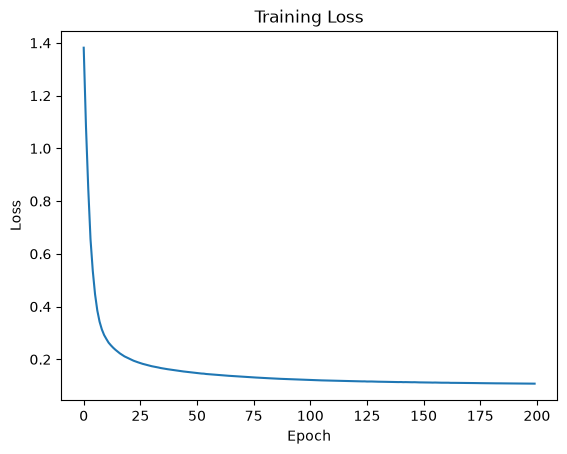

In [9]:
# Plot training loss
loss = h.history['loss']

plt.close()
plt.plot(loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.show()